<a href="https://colab.research.google.com/github/RishabKrPandey/Predicting-Irrigation-Needs/blob/main/agri_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [2]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

### EDA

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [ ]:
train.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [4]:
test_id = test['id']

### Data Preprocessing

In [5]:
def preprocess_data(df, is_train=True):
    df = df.copy()

    # Drop identifiers
    if 'id' in df.columns:
        df = df.drop('id', axis=1)

    # Convert 'Yes'/'No' to 1/0
    if 'Mulching_Used' in df.columns:
        df['Mulching_Used'] = df['Mulching_Used'].map({'Yes': 1, 'No': 0})

    # Convert text columns to LightGBM categories
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

    # Exclude the target variable from categorical conversion if it's the training set
    if is_train and 'Irrigation_Need' in categorical_cols:
        categorical_cols.remove('Irrigation_Need')

    for col in categorical_cols:
        df[col] = df[col].astype('category')

    return df

In [6]:
# Apply preprocessing
train_processed = preprocess_data(train, is_train=True)
test_processed = preprocess_data(test, is_train=False)

In [7]:
# Map target variable to integers
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
train_processed['Irrigation_Need'] = train_processed['Irrigation_Need'].map(target_mapping)

In [8]:
# Define features and target
X = train_processed.drop('Irrigation_Need', axis=1)
y = train_processed['Irrigation_Need']

### Stratified K-Fold Cross Validation

In [9]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

# Array to store the balanced accuracy of each fold
balanced_accuracies = []
models = [] # List to store every trained model

### Training loop

In [10]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    # Split data into training and validation for this fold
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # class_weight='balanced', it forces the model
    # to heavily penalize errors made on the rare 'High' class.
    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # Train the model
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # Predict on the validation set
    y_pred = model.predict(X_val)

    # Calculate Balanced Accuracy
    fold_score = balanced_accuracy_score(y_val, y_pred)
    balanced_accuracies.append(fold_score)

    models.append(model)

    print(f"Fold {fold} Balanced Accuracy: {fold_score:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031722 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2703
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 19
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Fold 1 Balanced Accuracy: 0.9685
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030552 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2704
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 19
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score

In [11]:
print("-" * 30)
print(f"Average Balanced Accuracy: {np.mean(balanced_accuracies):.4f} ± {np.std(balanced_accuracies):.4f}\n")

------------------------------
Average Balanced Accuracy: 0.9692 ± 0.0007



### Submission

In [12]:
# Create an array of zeros to hold the predicted probabilities for 3 classes
test_predictions = np.zeros((len(test_processed), 3))

In [13]:
# Add up the probabilities from each trained fold model
for model in models:
    test_predictions += model.predict_proba(test_processed) / 5

In [14]:
# Take the class with the highest average probability
final_preds_int = np.argmax(test_predictions, axis=1)

In [15]:
# Map the integer predictions back to the original strings
reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
final_preds_str = [reverse_mapping[pred] for pred in final_preds_int]

In [16]:
# Create the submission DataFrame
submission = pd.DataFrame({
    'id': test_id,
    'Irrigation_Need': final_preds_str
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("Successfully created 'submission.csv'!")

Successfully created 'submission.csv'!


In [17]:
!pip install shap

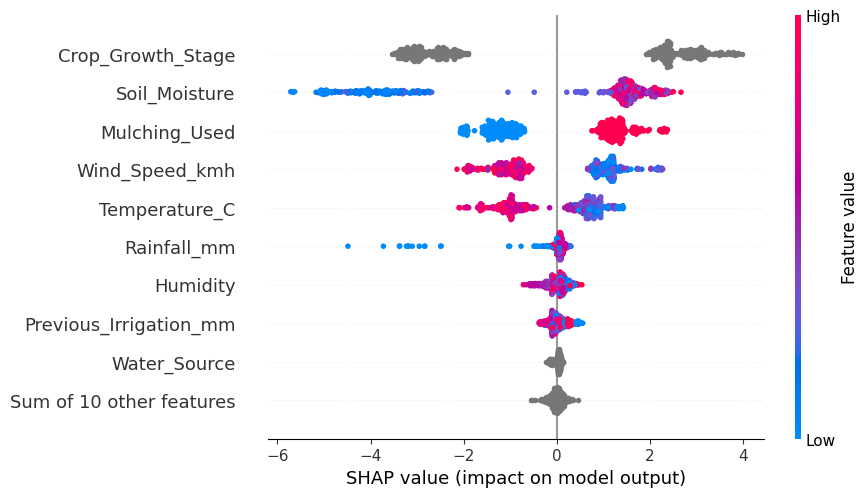

In [18]:
import shap

final_model = models[-1]

sample_X = X_val.sample(500, random_state=42)

explainer = shap.Explainer(final_model)

shap_values = explainer(sample_X)

# Select one class (example: class 0)
shap.plots.beeswarm(shap_values[:, :, 0])

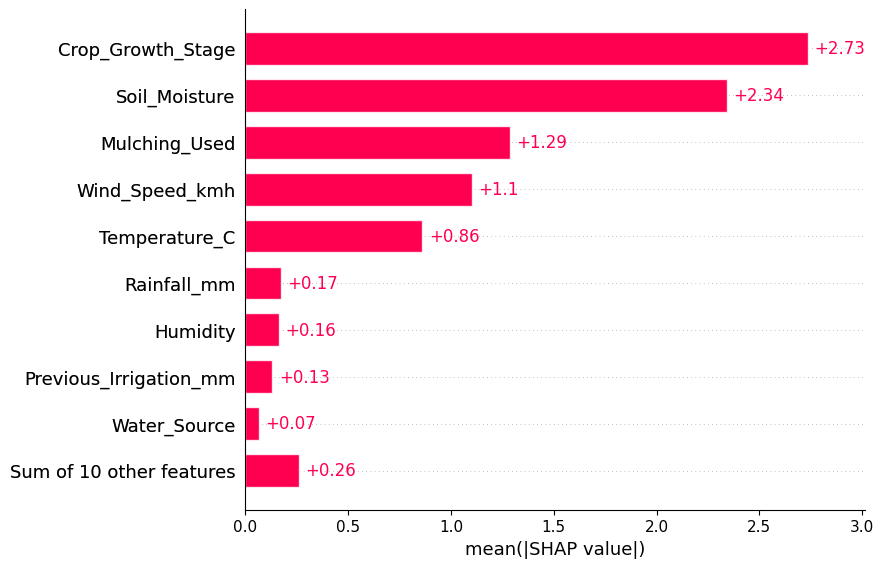

In [19]:
shap.plots.bar(shap_values[:, :, 0])

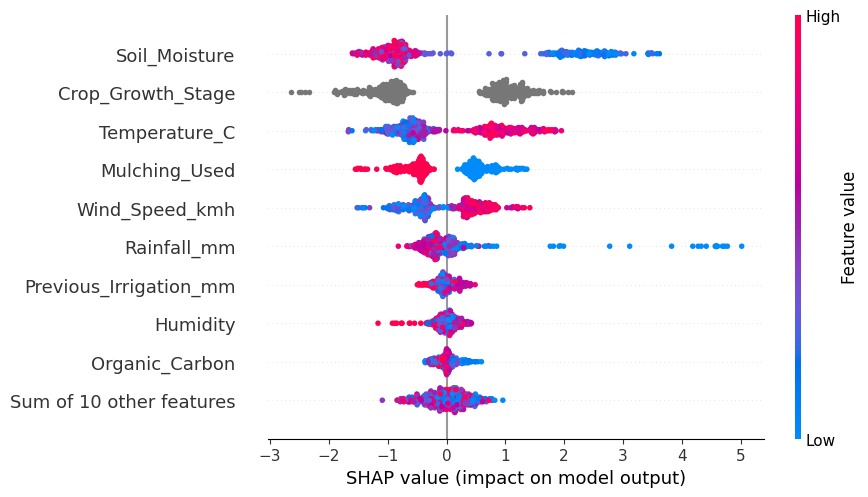

In [20]:
shap.plots.beeswarm(shap_values[:, :, 2])